<a href="https://colab.research.google.com/github/Maryam-Skaik/beyond-the-scoreboard/blob/main/notebooks/sports_fan_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beyond the Scoreboard:
## Discovering Hidden Sports Fan Personas with Data

### Business Problem

Sports organizations often treat all fans the same.

However, not all fans engage with sports in the same way.

Some fans spend heavily on merchandise and attend live events, while others primarily consume sports through social media or streaming platforms.

Understanding these differences enables sports organizations, broadcasters, and marketing teams to create targeted engagement strategies.

### Project Objectives
- Explore global sports fan behavior
- Identify key engagement patterns
- Discover hidden fan personas using clustering
- Generate actionable business recommendations

### Dataset
Global Sports Fan Survey 2024

Records: 2,200 sports fans

Countries: 15

Sports Covered: 26

## Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)

## Load Dataset

In [ ]:
fpath = '/content/drive/MyDrive/Looker_Studio/Data/sports_fan_survey_2024.csv'
df = pd.read_csv(fpath)
df.head()

,respondent_id,survey_year,survey_month,survey_platform,response_time_minutes,country,region,age,gender,education_level,employment_status,income_bracket,primary_sport,sport_category,secondary_sport,years_following_sport,fan_loyalty_score,primary_viewing_method,watch_frequency,weekly_hours_watching,streaming_subscriptions,stadium_visits_per_year,merchandise_spend_usd,ppv_spend_usd,total_annual_spend_usd,social_media_follows_athletes,social_media_hours_weekly,creates_sports_content,news_source,sports_betting_participation,fantasy_sports_participation,primary_motivation,willing_to_attend_major_event,extra_spend_willingness_usd,broadcast_quality_rating,athlete_professionalism_rating,event_value_for_money_rating,media_coverage_rating,community_atmosphere_rating,overall_satisfaction_rating,sport_growth_perception_rating,fan_tier
0,1,2024,8,In-app,16,Brazil,South America,59,Female,Bachelor's degree,Employed full-time,$50k–$75k,MMA,Combat Sport,Volleyball,17,3,Cable/satellite TV,Several times a week,11.1,0,1,18,26,44,Yes,0.9,No,TV sports news,No,No,Gambling/betting,Maybe,17.82,5,9,1,8,5,10,1,Silver
1,2,2024,12,Online (desktop),14,China,East Asia,42,Male,Doctorate,Employed part-time,$100k–$150k,Basketball,Team Sport,Table Tennis,6,2,Cable/satellite TV,Several times a week,5.3,5,1,25,90,115,Yes,2.5,No,TV sports news,No,No,Entertainment,Definitely yes,7.26,10,7,8,8,7,7,10,Silver
2,3,2024,10,Online (desktop),13,Canada,North America,46,Female,Master's degree,Student,$25k–$50k,Soccer,Team Sport,NaN,8,1,Cable/satellite TV,Several times a week,12.7,2,1,2,24,26,Yes,5.2,No,TV sports news,No,Yes,Gambling/betting,Probably yes,19.59,6,8,5,8,9,7,10,Bronze
3,4,2024,2,Online (mobile),11,Australia,Oceania,27,Male,Master's degree,Student,$25k–$50k,Rugby,Team Sport,NaN,16,4,Sports bar/pub,A few times a month,3.7,0,0,106,6,112,Yes,5.1,No,Social media,No,No,Community & belonging,Probably not,8.44,5,9,5,7,10,7,9,Gold
4,5,2024,10,In-app,6,USA,North America,22,Male,High school,Retired,$75k–$100k,American Football,Team Sport,NaN,5,2,Streaming service,A few times a month,2.1,2,1,32,19,51,Yes,3.4,No,Social media,No,Yes,Athletic excellence,Definitely yes,17.80,7,7,5,4,9,9,6,Bronze


### Initial Data Overview

The dataset captures sports fan behavior from multiple perspectives, combining demographic information, spending habits, media consumption patterns, engagement activities, and satisfaction ratings.

Several feature groups appear particularly valuable for analysis:

- **Fan Profile Features**
  - Age
  - Gender
  - Education level
  - Employment status
  - Income bracket
  - Country and region

- **Sports Preference Features**
  - Primary sport
  - Secondary sport
  - Sport category
  - Years following sport
  - Fan loyalty score

- **Consumption & Engagement Features**
  - Viewing method
  - Watch frequency
  - Weekly viewing hours
  - Streaming subscriptions
  - Stadium visits
  - Social media activity

- **Spending Features**
  - Merchandise spending
  - Pay-per-view spending
  - Total annual sports spending
  - Additional spending willingness

- **Participation Features**
  - Fantasy sports participation
  - Sports betting participation
  - Sports content creation

- **Perception & Satisfaction Features**
  - Broadcast quality rating
  - Event value rating
  - Media coverage rating
  - Community atmosphere rating
  - Overall satisfaction rating
  - Sport growth perception rating

These variables provide a rich foundation for identifying different types of sports fans, understanding engagement behavior, and uncovering meaningful audience segments through clustering.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 42 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   respondent_id                   2200 non-null   int64  
 1   survey_year                     2200 non-null   int64  
 2   survey_month                    2200 non-null   int64  
 3   survey_platform                 2200 non-null   object 
 4   response_time_minutes           2200 non-null   int64  
 5   country                         2200 non-null   object 
 6   region                          2200 non-null   object 
 7   age                             2200 non-null   int64  
 8   gender                          2200 non-null   object 
 9   education_level                 2200 non-null   object 
 10  employment_status               2200 non-null   object 
 11  income_bracket                  2200 non-null   object 
 12  primary_sport                   22

### Dataset Structure & Data Quality

The dataset contains **2,200 survey responses** and **42 features**, providing a sufficiently rich sample for both exploratory analysis and customer segmentation.

A review of the data types shows a balanced mix of:

- **Categorical variables (20 columns)** describing demographics, sports preferences, engagement channels, motivations, and fan classifications.
- **Numerical variables (22 columns)** capturing spending behavior, viewing habits, loyalty levels, participation frequency, and satisfaction ratings.

Most importantly, the dataset is highly complete:
- Nearly all variables contain **no missing values**.
- Only **`secondary_sport`** contains missing observations, suggesting that many respondents may follow a single sport rather than multiple sports.
- No immediate data quality concerns are visible from the structure overview.

The presence of both behavioral and demographic variables makes the dataset well-suited for:
- Exploratory Data Analysis (EDA)
- Feature engineering
- Fan segmentation through clustering
- Profiling distinct sports fan personas

The numerical features will be particularly valuable for clustering since they quantify engagement intensity, spending patterns, media consumption, loyalty, and satisfaction levels.

In [ ]:
df.describe(include='all').round(2)

,respondent_id,survey_year,survey_month,survey_platform,response_time_minutes,country,region,age,gender,education_level,employment_status,income_bracket,primary_sport,sport_category,secondary_sport,years_following_sport,fan_loyalty_score,primary_viewing_method,watch_frequency,weekly_hours_watching,streaming_subscriptions,stadium_visits_per_year,merchandise_spend_usd,ppv_spend_usd,total_annual_spend_usd,social_media_follows_athletes,social_media_hours_weekly,creates_sports_content,news_source,sports_betting_participation,fantasy_sports_participation,primary_motivation,willing_to_attend_major_event,extra_spend_willingness_usd,broadcast_quality_rating,athlete_professionalism_rating,event_value_for_money_rating,media_coverage_rating,community_atmosphere_rating,overall_satisfaction_rating,sport_growth_perception_rating,fan_tier
count,2200.00,2200.0,2200.00,2200,2200.00,2200,2200,2200.00,2200,2200,2200,2200,2200,2200,1232,2200.00,2200.00,2200,2200,2200.00,2200.00,2200.00,2200.0,2200.00,2200.00,2200,2200.00,2200,2200,2200,2200,2200,2200,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200
unique,NaN,NaN,NaN,4,NaN,15,7,NaN,4,6,6,6,26,4,26,NaN,NaN,7,5,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2,5,2,2,8,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,Online (mobile),NaN,USA,Europe,NaN,Male,Bachelor's degree,Employed full-time,$50k–$75k,Soccer,Team Sport,Tennis,NaN,NaN,Streaming service,Several times a week,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN,No,Social media,No,No,Entertainment,Probably yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Silver
freq,NaN,NaN,NaN,934,NaN,424,520,NaN,1260,823,1049,504,608,1704,211,NaN,NaN,698,730,NaN,NaN,NaN,NaN,NaN,NaN,1609,NaN,1967,737,1523,1384,570,641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,836
mean,1100.50,2024.0,6.52,NaN,13.03,NaN,NaN,33.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.38,3.34,NaN,NaN,6.89,1.88,1.26,56.6,34.10,90.70,NaN,2.57,NaN,NaN,NaN,NaN,NaN,NaN,8.80,7.24,6.70,5.91,7.01,7.41,7.49,7.06,NaN
std,635.23,0.0,3.46,NaN,3.94,NaN,NaN,10.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.72,1.42,NaN,NaN,4.65,1.67,1.52,84.7,46.67,105.61,NaN,1.61,NaN,NaN,NaN,NaN,NaN,NaN,11.53,1.56,1.82,2.02,1.63,1.49,1.45,1.78,NaN
min,1.00,2024.0,1.00,NaN,4.00,NaN,NaN,18.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00,1.00,NaN,NaN,0.50,0.00,0.00,0.0,0.00,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,0.00,2.00,1.00,1.00,1.00,2.00,3.00,1.00,NaN
25%,550.75,2024.0,4.00,NaN,10.00,NaN,NaN,25.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00,2.00,NaN,NaN,3.10,1.00,0.00,9.0,6.00,27.00,NaN,1.30,NaN,NaN,NaN,NaN,NaN,NaN,1.80,6.00,5.00,5.00,6.00,6.00,7.00,6.00,NaN
50%,1100.50,2024.0,6.00,NaN,13.00,NaN,NaN,33.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.00,3.00,NaN,NaN,6.40,1.00,1.00,27.0,19.00,57.00,NaN,2.55,NaN,NaN,NaN,NaN,NaN,NaN,4.67,7.00,7.00,6.00,7.00,7.00,8.00,7.00,NaN
75%,1650.25,2024.0,10.00,NaN,16.00,NaN,NaN,41.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.00,4.00,NaN,NaN,9.70,3.00,2.00,69.0,44.00,114.00,NaN,3.70,NaN,NaN,NaN,NaN,NaN,NaN,11.22,8.00,8.00,7.00,8.00,8.00,9.00,8.00,NaN


### Descriptive Statistics Insights

The summary statistics provide an initial understanding of how sports fans engage, spend, and interact with their favorite sports.

Key observations include:

- The average respondent is **33 years old**, with ages ranging from **18 to 65**, indicating representation across multiple age groups.
- Fans have followed their primary sport for an average of **13 years**, suggesting that many respondents have long-term connections with their chosen sport.
- The average **fan loyalty score** is **3.34 out of 8**, indicating noticeable variation in commitment levels across the audience.

Engagement behavior also varies considerably:

- Fans spend approximately **7 hours per week** watching sports on average.
- Stadium attendance is relatively modest, with a median of **1 visit per year**.
- Social media engagement averages **2.6 hours per week**, although some fans report substantially higher activity levels.

Spending patterns reveal strong differences between respondents:
- Average annual sports-related spending is approximately **`$91`**, while the maximum exceeds **`$1,000`**.
- Merchandise and pay-per-view expenditures show large standard deviations, suggesting the presence of both low-spending casual fans and highly invested supporters.
- The wide range in **extra spending willingness** further indicates differing levels of financial commitment.

Fan perception metrics show generally positive attitudes:
- Most satisfaction and rating variables have median values between **7 and 8 out of 10**.
- **Broadcast quality**, **overall satisfaction**, and **community atmosphere** receive particularly strong evaluations.
- Variation in these ratings may help explain differences in fan engagement and loyalty.

Several categorical distributions are also noteworthy:
- The survey is dominated by **mobile respondents**, reflecting modern digital consumption habits.
- **Soccer** is the most frequently selected primary sport.
- **Streaming services** represent the most common viewing method.
- Most respondents do not participate in sports betting, fantasy sports, or sports content creation.
- The most common fan tier is **Silver**, suggesting a large middle segment between casual and highly engaged fans.

Overall, the statistics indicate substantial diversity in spending behavior, engagement intensity, loyalty, and consumption habits—strong signals that meaningful fan segments are likely to emerge during the clustering stage.

## Data Quality Assessment

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
secondary_sport,968
respondent_id,0
survey_month,0
survey_platform,0
response_time_minutes,0
country,0
region,0
age,0
gender,0
survey_year,0


In [ ]:
(df.isnull().sum()/len(df))*100

,0
respondent_id,0.0
survey_year,0.0
survey_month,0.0
survey_platform,0.0
response_time_minutes,0.0
country,0.0
region,0.0
age,0.0
gender,0.0
education_level,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

### Missing Values & Data Quality Assessment

A missing value analysis reveals that the dataset is exceptionally complete.

- Out of 42 features, **41 contain no missing values**.
- Only **`secondary_sport`** has missing observations, with **968 missing values (44%)**.
- No duplicate records were detected, indicating that each survey response represents a unique participant.

The missing values in `secondary_sport` appear to be meaningful rather than random. Since this feature captures an additional sport followed by a respondent, a missing value likely indicates that the respondent does not actively follow a second sport.

For this reason, traditional imputation methods such as replacing missing values with the mode would introduce misleading information by assigning a secondary sport to respondents who may not have one.

**Recommended treatment:**
- Replace missing values in `secondary_sport` with a category such as **"None"**, **"No Secondary Sport"**, or **"Single-Sport Fan"**.
- This preserves potentially valuable behavioral information while avoiding artificial assumptions about fan interests.

```python
df['secondary_sport'] = df['secondary_sport'].fillna('No Secondary Sport')
```

After handling `secondary_sport`, the dataset becomes fully complete and ready for exploratory analysis, feature engineering, and clustering without requiring further missing-value treatment.

## Understanding Sports Fans

### Which sports are most popular?

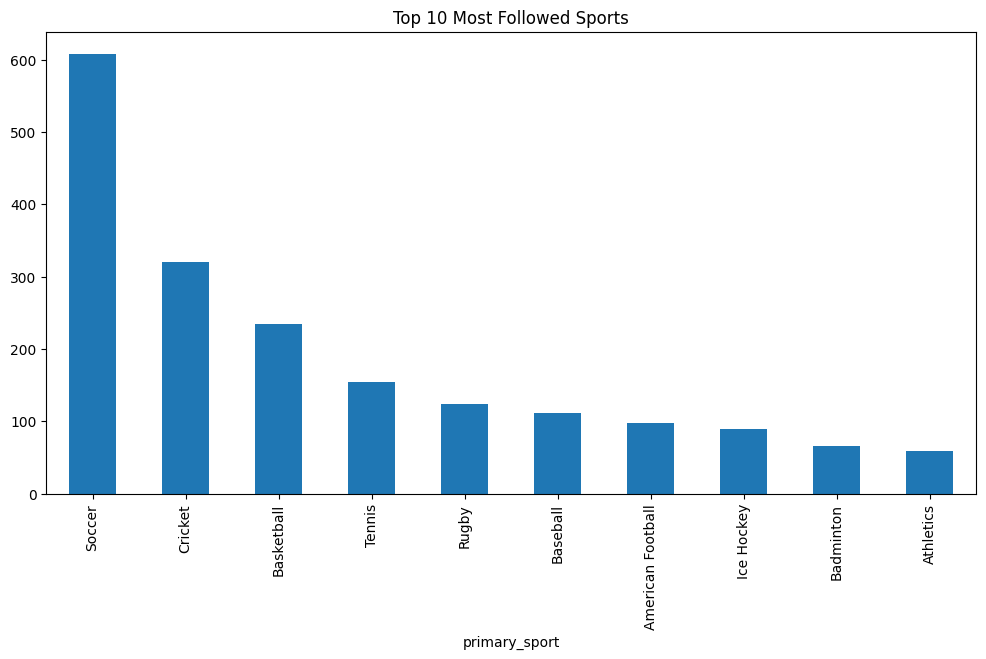

In [ ]:
plt.figure(figsize=(12,6))

df['primary_sport'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Most Followed Sports")
plt.show();

#### Most Followed Sports

The distribution of primary sports reveals a clear hierarchy in fan preferences across the survey population.

Key observations include:

- **Soccer is the dominant sport**, attracting substantially more followers than any other sport in the dataset.
- **Cricket and Basketball** form a strong second tier, maintaining significant popularity but remaining well behind Soccer.
- **Tennis and Rugby** occupy the middle range, indicating solid but more specialized fan bases.
- The remaining sports in the top 10 exhibit relatively similar follower counts, suggesting a more balanced distribution of interest among these categories.

The overall pattern reflects a **highly concentrated fan landscape**, where a small number of globally popular sports capture the majority of attention while many other sports share smaller but meaningful audiences.

From a business perspective, this suggests that sports organizations may benefit from balancing broad engagement strategies aimed at major sports with more targeted approaches designed for niche fan communities.

These differences in sport preference may also contribute to the formation of distinct fan personas during the clustering phase, as followers of different sports are likely to exhibit varying engagement habits, spending behaviors, and motivations.

### Age Distribution

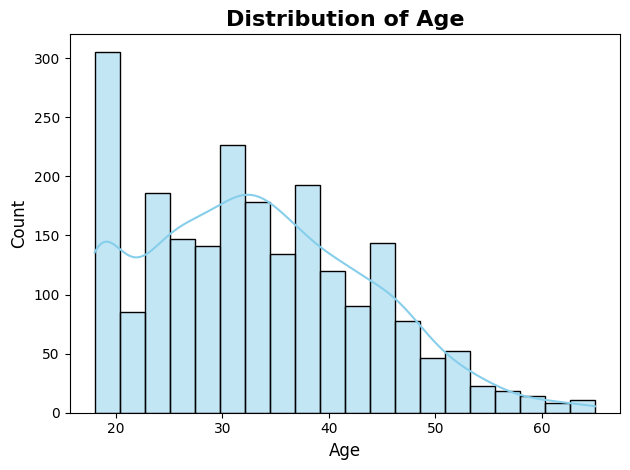

In [ ]:
sns.histplot(df['age'], bins=20, kde=True, color='skyblue', edgecolor='black')

plt.title('Distribution of Age', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show();

#### Age Distribution of Sports Fans

The age distribution provides insight into the demographic composition of the surveyed sports fans.

Key observations include:
- The distribution is **positively skewed**, indicating that younger individuals make up a larger proportion of the dataset than older age groups.
- A pronounced concentration appears among respondents in the **late teens and early twenties**, making this the largest age segment in the survey.
- A second notable concentration is visible among fans in their **thirties**, suggesting strong engagement from both young adults and mature adults.
- After approximately age 45, the number of respondents declines steadily, with relatively few participants represented in the oldest age groups.

The density curve further suggests that the data is not centered around a single age group. Instead, it exhibits **multiple peaks**, indicating the presence of distinct age segments within the sports fan population.

From a business perspective, these findings suggest that sports organizations must appeal to audiences at different life stages. Younger fans may engage more through digital platforms and social media, while older fans may exhibit different viewing habits, spending patterns, and loyalty characteristics.

Age is therefore likely to be an important variable in identifying fan personas and understanding differences in engagement behavior throughout the clustering analysis.

### Viewing Habits

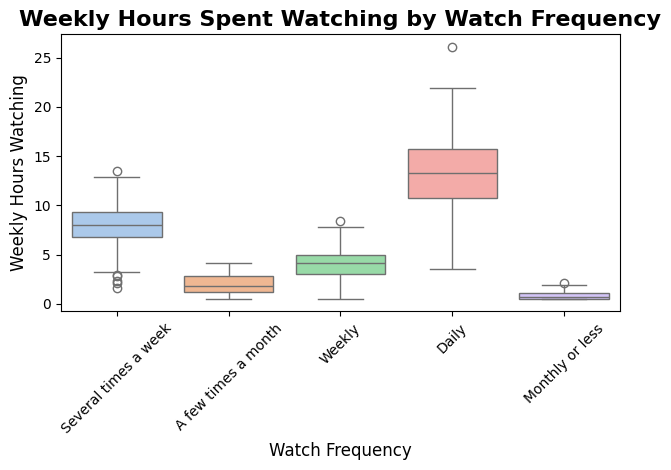

In [ ]:
sns.boxplot(
    x='watch_frequency',
    y='weekly_hours_watching',
    data=df,
    palette='pastel'
)

plt.title('Weekly Hours Spent Watching by Watch Frequency', fontsize=16, fontweight='bold')
plt.xlabel('Watch Frequency', fontsize=12)
plt.ylabel('Weekly Hours Watching', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show();

#### Viewing Frequency vs. Weekly Watching Hours

The relationship between viewing frequency and weekly watching hours reveals clear differences in engagement intensity among sports fans.

Key observations include:
- Fans who watch sports **daily** record the highest weekly viewing time, with a substantially larger median than all other groups.
- The **"Several times a week"** segment represents another highly engaged audience, accumulating a considerable number of viewing hours despite not watching every day.
- Respondents who watch sports **weekly** spend more total viewing time than those who watch only a few times per month, reflecting a higher level of consistency in consumption.
- The **"Monthly or less"** group exhibits the lowest viewing hours and the smallest variation, indicating a largely casual audience with limited engagement.

The spread of the distributions also provides useful insights:

- High-frequency viewers show greater variability in viewing hours, suggesting that even among highly engaged fans, consumption habits differ considerably.
- Several outliers are present, particularly among daily viewers, indicating a small group of exceptionally dedicated fans who consume sports content at very high levels.

Overall, the chart demonstrates a strong positive relationship between viewing frequency and total viewing hours. As viewing frequency increases, sports consumption generally rises as well.

This finding suggests that viewing behavior can serve as an important indicator of fan engagement and may play a significant role in distinguishing casual viewers from highly committed fans during the clustering process.

### Spending Behavior

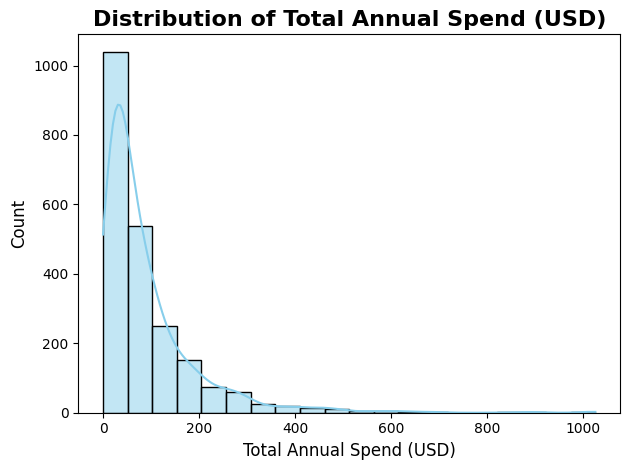

In [ ]:
sns.histplot(
    data=df,
    x='total_annual_spend_usd',
    bins=20,
    kde=True,
    color='skyblue',
    edgecolor='black'
)

plt.title('Distribution of Total Annual Spend (USD)', fontsize=16, fontweight='bold')
plt.xlabel('Total Annual Spend (USD)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

#### Distribution of Total Annual Sports Spending

The distribution of total annual spending reveals substantial differences in financial commitment among sports fans.

Key observations include:

- The distribution is **strongly right-skewed**, with most respondents concentrated in the lower spending ranges.
- A large proportion of fans spend relatively modest amounts on sports-related activities, merchandise, subscriptions, and events each year.
- The number of respondents decreases rapidly as spending levels increase, indicating that high-spending fans represent a much smaller segment of the audience.
- A long tail extends toward very high spending values, demonstrating the presence of a limited group of fans who invest significantly more than the average respondent.

The distribution also highlights notable spending inequality:

- Most fans appear to fall within a relatively low-to-moderate spending range.
- A small number of respondents contribute disproportionately high spending amounts, with annual expenditures exceeding $1,000.
- These extreme values likely represent highly engaged supporters who regularly purchase merchandise, attend events, subscribe to multiple services, or participate in premium sports experiences.

From a business perspective, this pattern suggests that sports audiences are not financially homogeneous. While the majority of fans generate moderate revenue, a relatively small group of high-value supporters may contribute a substantial share of overall spending.

This variation makes spending behavior a particularly important feature for fan segmentation, as it can help distinguish casual followers from premium and highly invested sports consumers during the clustering phase.

### Social Media Engagement

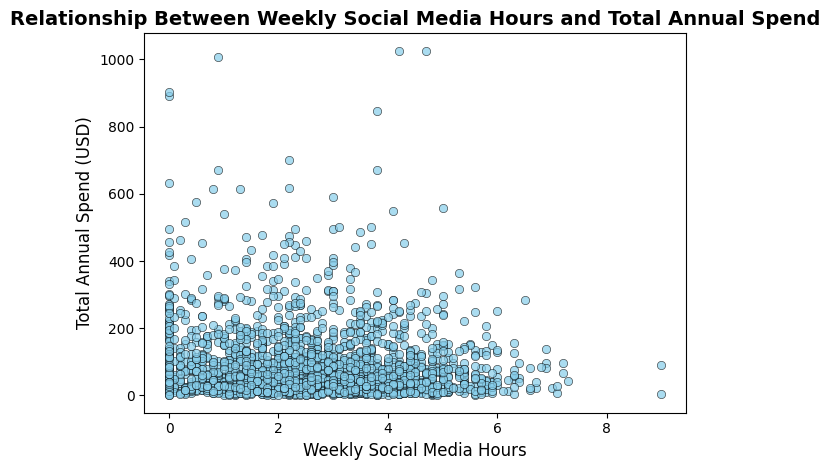

In [ ]:
sns.scatterplot(
    data=df,
    x='social_media_hours_weekly',
    y='total_annual_spend_usd',
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.title('Relationship Between Weekly Social Media Hours and Total Annual Spend', fontsize=14, fontweight='bold')
plt.xlabel('Weekly Social Media Hours', fontsize=12)
plt.ylabel('Total Annual Spend (USD)', fontsize=12)

plt.tight_layout()
plt.show();

### Social Media Engagement vs. Total Annual Spending

The scatter plot explores the relationship between weekly social media usage and total annual sports spending.

Key observations include:

- There is **no clear linear relationship** between social media activity and annual spending. High and low spenders appear across all levels of social media usage.
- The data is heavily concentrated in the **lower-left region**, where most respondents spend fewer than 4 hours per week on social media and less than \$200 annually on sports-related activities.
- A subtle boundary pattern appears in the upper range: **higher spending values are mostly observed among users with lower social media usage**, while high social media users rarely appear among top spenders.
- Extremely high spenders (above \$600) are sparse and tend to cluster within the low-to-moderate social media usage range.
- Users with **very high social media activity (6+ hours weekly)** are relatively rare and generally associated with lower spending levels.

Overall, the relationship suggests that social media usage alone is not a strong predictor of financial contribution in sports consumption. Instead, spending behavior appears to be influenced by other factors such as fan loyalty, sport type, or engagement intensity rather than purely digital activity.

This insight supports the idea that fan segmentation should combine multiple behavioral dimensions rather than relying on a single engagement metric.

## Feature Selection for Clustering

In [ ]:
cluster_features = [
    # Engagement & loyalty
    'fan_loyalty_score',
    'weekly_hours_watching',
    'watch_frequency',

    # Digital behavior
    'streaming_subscriptions',
    'social_media_hours_weekly',

    # Offline engagement
    'stadium_visits_per_year',

    # Spending behavior
    'merchandise_spend_usd',
    'ppv_spend_usd',
    'extra_spend_willingness_usd',

    # Context (very important)
    'primary_motivation',
    'age',
    'income_bracket'
]

### Feature Selection for Clustering

To build meaningful sports fan personas, the clustering features were selected to capture multiple dimensions of fan behavior, rather than relying on a single type of activity.

The chosen features can be grouped into four main categories:

#### Engagement & Loyalty
- fan_loyalty_score  
- weekly_hours_watching  
- watch_frequency  

These variables measure how consistently and intensely fans follow sports content, forming the core of behavioral engagement.

#### Digital Behavior
- streaming_subscriptions  
- social_media_hours_weekly  

These features represent how fans interact with sports through digital platforms, including streaming services and social media activity.

#### Offline Engagement
- stadium_visits_per_year  

This captures real-world participation in sports events, distinguishing in-person fans from purely digital audiences.

#### Spending Behavior
- merchandise_spend_usd  
- ppv_spend_usd  
- extra_spend_willingness_usd  

These variables reflect financial commitment and purchasing behavior, helping differentiate low-value and high-value fan segments.

#### Contextual & Demographic Features
- primary_motivation  
- age  
- income_bracket  

These features provide essential context for interpreting behavioral differences, ensuring that clusters reflect not only actions but also underlying drivers such as motivation, life stage, and financial capacity.


Overall, this feature set balances behavioral, financial, digital, and contextual dimensions, which is critical for producing interpretable and actionable sports fan personas through clustering.

## Encoding & Scaling

In [ ]:
df[cluster_features]

,fan_loyalty_score,weekly_hours_watching,watch_frequency,streaming_subscriptions,social_media_hours_weekly,stadium_visits_per_year,merchandise_spend_usd,ppv_spend_usd,extra_spend_willingness_usd,primary_motivation,age,income_bracket
0,3,11.1,Several times a week,0,0.9,1,18,26,17.82,Gambling/betting,59,$50k–$75k
1,2,5.3,Several times a week,5,2.5,1,25,90,7.26,Entertainment,42,$100k–$150k
2,1,12.7,Several times a week,2,5.2,1,2,24,19.59,Gambling/betting,46,$25k–$50k
3,4,3.7,A few times a month,0,5.1,0,106,6,8.44,Community & belonging,27,$25k–$50k
4,2,2.1,A few times a month,2,3.4,1,32,19,17.80,Athletic excellence,22,$75k–$100k
...,...,...,...,...,...,...,...,...,...,...,...,...
2195,1,8.9,Several times a week,3,0.0,1,4,128,41.07,Gambling/betting,48,Over $150k
2196,3,9.0,Several times a week,0,3.6,0,90,45,10.38,Entertainment,26,$25k–$50k
2197,4,15.9,Daily,0,3.2,0,2,8,0.84,Community & belonging,39,Under $25k
2198,4,9.7,Several times a week,3,1.8,2,111,76,2.70,Social bonding,32,$100k–$150k


In [ ]:
cat_cols = ['primary_motivation', 'income_bracket', 'watch_frequency']
num_cols = [
    'fan_loyalty_score',
    'weekly_hours_watching',
    'streaming_subscriptions',
    'social_media_hours_weekly',
    'stadium_visits_per_year',
    'merchandise_spend_usd',
    'ppv_spend_usd',
    'extra_spend_willingness_usd',
    'age'
]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_encoded = ohe.fit_transform(df[cat_cols])
cat_encoded_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(cat_cols), index=df.index)

X = pd.concat([df[num_cols], cat_encoded_df], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Feature Encoding and Scaling for Clustering

Before applying clustering algorithms, the dataset was preprocessed to ensure all features are in a suitable numerical format and on a comparable scale.

#### Categorical Feature Encoding

Categorical variables were transformed using One-Hot Encoding to convert them into a machine-readable numerical format without introducing ordinal relationships.
- primary_motivation  
- income_bracket  
- watch_frequency  

This step ensures that each category is represented independently, allowing the clustering algorithm to treat them fairly without assuming any inherent ranking.

#### Numerical Features

The following continuous and ordinal features were selected as-is for scaling:
- fan_loyalty_score  
- weekly_hours_watching  
- streaming_subscriptions  
- social_media_hours_weekly  
- stadium_visits_per_year  
- merchandise_spend_usd  
- ppv_spend_usd  
- extra_spend_willingness_usd  
- age  

These variables represent behavioral intensity, spending patterns, and demographic context.

#### Feature Integration
After encoding, the dataset was reconstructed by concatenating numerical features with the encoded categorical variables, forming a unified feature matrix suitable for clustering.

#### Feature Scaling
Standardization was applied using `StandardScaler` to ensure all features contribute equally to distance-based clustering methods.

- This step removes scale bias (e.g., spending values vs. rating scales)
- Ensures clustering is driven by patterns, not magnitude differences

The resulting dataset is now fully numerical, normalized, and ready for clustering algorithms such as K-Means.

## Finding Optimal K

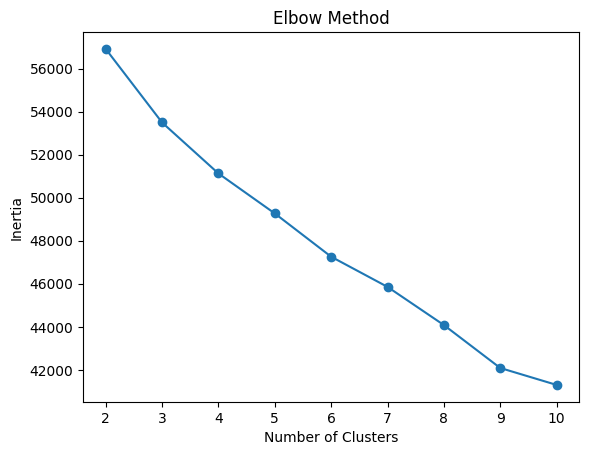

In [ ]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show();

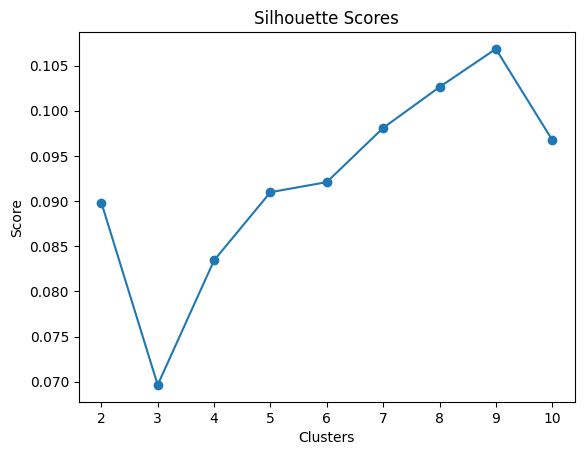

In [ ]:
sil_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 11), sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("Clusters")
plt.ylabel("Score")
plt.show();

### Selecting the Optimal Number of Clusters

To determine the appropriate number of clusters for K-Means, two evaluation methods were applied: the Elbow Method (Inertia) and the Silhouette Score.

The Elbow Method showed a gradual and continuous decrease in inertia as the number of clusters increased. However, no clear inflection point was observed, making it difficult to identify an optimal value based solely on this metric.

The Silhouette Score provided additional insight into cluster quality by measuring separation and cohesion between clusters. While the scores remained relatively low across all tested values, a slight peak was observed at higher values of K. However, relying solely on the highest silhouette score would lead to an overly fragmented segmentation that is difficult to interpret from a business perspective.

Given this trade-off between mathematical optimization and interpretability, a balanced decision was made.

#### Final Choice: K = 5

Five clusters were selected as the optimal solution because:

- It provides a **balanced segmentation** between underfitting (too few clusters) and overfitting (too many clusters)
- It maintains **interpretability**, which is essential for defining actionable fan personas
- It captures meaningful variation in engagement, spending, and behavior without excessive fragmentation
- It aligns well with the objective of the project, which is to identify **distinct but understandable sports fan personas**

This choice prioritizes practical usability over marginal improvements in evaluation metrics, ensuring that the resulting clusters can be effectively analyzed and translated into business insights.

## Final Clustering

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,respondent_id,survey_year,survey_month,survey_platform,response_time_minutes,country,region,age,gender,education_level,employment_status,income_bracket,primary_sport,sport_category,secondary_sport,years_following_sport,fan_loyalty_score,primary_viewing_method,watch_frequency,weekly_hours_watching,streaming_subscriptions,stadium_visits_per_year,merchandise_spend_usd,ppv_spend_usd,total_annual_spend_usd,social_media_follows_athletes,social_media_hours_weekly,creates_sports_content,news_source,sports_betting_participation,fantasy_sports_participation,primary_motivation,willing_to_attend_major_event,extra_spend_willingness_usd,broadcast_quality_rating,athlete_professionalism_rating,event_value_for_money_rating,media_coverage_rating,community_atmosphere_rating,overall_satisfaction_rating,sport_growth_perception_rating,fan_tier,cluster
0,1,2024,8,In-app,16,Brazil,South America,59,Female,Bachelor's degree,Employed full-time,$50k–$75k,MMA,Combat Sport,Volleyball,17,3,Cable/satellite TV,Several times a week,11.1,0,1,18,26,44,Yes,0.9,No,TV sports news,No,No,Gambling/betting,Maybe,17.82,5,9,1,8,5,10,1,Silver,4
1,2,2024,12,Online (desktop),14,China,East Asia,42,Male,Doctorate,Employed part-time,$100k–$150k,Basketball,Team Sport,Table Tennis,6,2,Cable/satellite TV,Several times a week,5.3,5,1,25,90,115,Yes,2.5,No,TV sports news,No,No,Entertainment,Definitely yes,7.26,10,7,8,8,7,7,10,Silver,0
2,3,2024,10,Online (desktop),13,Canada,North America,46,Female,Master's degree,Student,$25k–$50k,Soccer,Team Sport,NaN,8,1,Cable/satellite TV,Several times a week,12.7,2,1,2,24,26,Yes,5.2,No,TV sports news,No,Yes,Gambling/betting,Probably yes,19.59,6,8,5,8,9,7,10,Bronze,3
3,4,2024,2,Online (mobile),11,Australia,Oceania,27,Male,Master's degree,Student,$25k–$50k,Rugby,Team Sport,NaN,16,4,Sports bar/pub,A few times a month,3.7,0,0,106,6,112,Yes,5.1,No,Social media,No,No,Community & belonging,Probably not,8.44,5,9,5,7,10,7,9,Gold,1
4,5,2024,10,In-app,6,USA,North America,22,Male,High school,Retired,$75k–$100k,American Football,Team Sport,NaN,5,2,Streaming service,A few times a month,2.1,2,1,32,19,51,Yes,3.4,No,Social media,No,Yes,Athletic excellence,Definitely yes,17.80,7,7,5,4,9,9,6,Bronze,1


In [ ]:
df['cluster'].value_counts()

,count
cluster,
4,840
3,438
0,426
1,255
2,241


In [ ]:
cluster_profile = df.groupby('cluster')[cluster_features].mean(numeric_only=True)

cluster_profile

,fan_loyalty_score,weekly_hours_watching,streaming_subscriptions,social_media_hours_weekly,stadium_visits_per_year,merchandise_spend_usd,ppv_spend_usd,extra_spend_willingness_usd,age
cluster,,,,,,,,,
0,3.490610,7.207746,3.711268,2.448357,2.748826,120.615023,74.931925,17.911643,34.234742
1,3.325490,1.961569,1.596078,2.415686,1.098039,47.968627,25.807843,7.410667,32.909804
2,3.232365,7.742739,0.556017,2.706639,0.315353,14.174274,8.323651,2.588631,33.713693
3,3.315068,7.525799,1.038813,2.677854,0.598174,28.598174,18.568493,4.503813,32.979452
4,3.315476,7.661429,1.851190,2.585238,1.169048,53.528571,31.405952,8.629536,32.676190


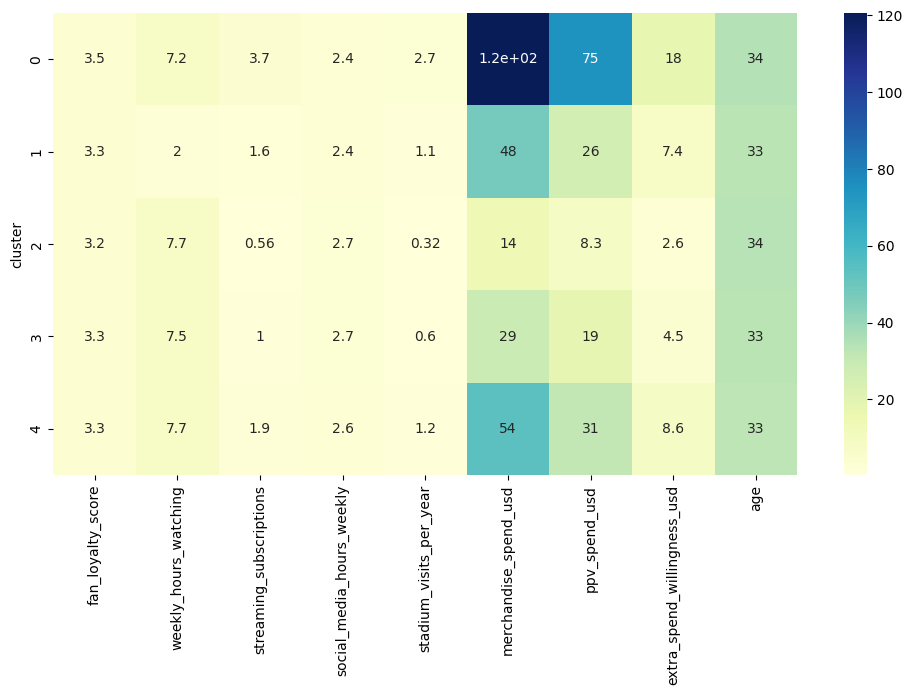

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu');

### K-Means Clustering Results (K = 5)

After applying K-Means clustering on the scaled feature set, the dataset was segmented into **five distinct fan personas**. Each cluster represents a unique combination of engagement behavior, spending patterns, and consumption habits.

The distribution of clusters is as follows:

- Cluster 0: 426 fans
- Cluster 1: 255 fans
- Cluster 2: 241 fans  
- Cluster 3: 438 fans  
- Cluster 4: 840 fans  

Cluster 4 is the largest segment, indicating a dominant mid-level fan group, while Clusters 1 and 2 represent smaller, more specialized audience segments.

### Cluster Profiles and Interpretations

#### **Cluster 0: Premium Superfans**
- Highest merchandise spending (~\$120)
- Highest PPV spending (~\$75)
- Strong extra spending willingness (~\$18)
- High overall engagement across multiple channels

**How it differs:**
- Clearly outperforms all other clusters in financial contribution
- Represents the most monetizable and high-value audience segment

#### **Cluster 1: Low-Engagement Minimal Spenders**
- Lowest weekly viewing hours (~2 hours)
- Lowest streaming subscriptions (~1.6)
- Low merchandise and PPV spending (~\$48 / \$26)
- Moderate baseline engagement behavior

**How it differs:**
- Lowest overall engagement intensity
- Financial contribution is limited despite presence in the ecosystem

#### **Cluster 2: Active Viewers, Low Converters**
- High weekly viewing hours (~7.7 hours)
- Very low merchandise spending (~\$14)
- Very low PPV spending (~\$8)
- Lowest stadium attendance and subscriptions

**How it differs:**
- Strong content consumption but extremely weak monetization
- Represents a “watch-heavy, buy-light” audience

#### **Cluster 3: Balanced Casual Fans**
- Moderate viewing hours (~7.5 hours)
- Low-to-moderate spending (~\$29 merch / \$19 PPV)
- Low stadium attendance
- Stable engagement across metrics

**How it differs:**
- Middle-ground behavior across most features
- Neither highly commercial nor purely passive

#### **Cluster 4: Core Mainstream Fans**
- Moderate merchandise spending (~\$53)
- Moderate PPV spending (~\$31)
- Consistent engagement across viewing and social metrics
- Highest stadium attendance among all clusters

**How it differs:**
- Largest and most stable group
- Represents the “base audience” of sports consumption

### Key Drivers Behind the Clusters

Although multiple features were included in the model, the clustering structure is primarily driven by a few dominant variables:

#### **1. Financial Behavior (Strongest Driver)**
- `merchandise_spend_usd`
- `ppv_spend_usd`
- `extra_spend_willingness_usd`

These features show the clearest separation between clusters and form the primary axis of segmentation.

#### **2. Engagement Intensity**
- `weekly_hours_watching`
- `stadium_visits_per_year`
- `streaming_subscriptions`

These variables differentiate high-consumption fans from passive viewers.

#### **3. Digital Activity**
- `social_media_hours_weekly`

This feature provides secondary separation but is less discriminative compared to spending and viewing behavior.

#### **4. Loyalty & Demographics (Weak Influence)**
- `fan_loyalty_score`
- `age`

These features show relatively low variance across clusters and therefore contribute less to separation.

### Overall Insight

The clustering reveals that **financial behavior is the strongest differentiator of sports fan personas**, followed by consumption intensity. In contrast, demographic factors and basic loyalty scores have minimal impact on cluster formation.

This confirms that sports fans are best segmented by **what they consume and how much they spend**, rather than who they are demographically.

### Business Recommendations

Based on the clustering results, sports fans can be grouped into clear behavioral segments. These segments can be used to design more effective marketing, pricing, and engagement strategies.

#### 1. Focus on High-Value Fans (Premium Superfans)
These fans spend the most on merchandise and pay-per-view content.

**Recommended actions:**
- Offer exclusive memberships or VIP packages
- Provide early access to tickets and limited-edition products
- Create loyalty rewards for repeat high spending
- Build premium experiences (behind-the-scenes, meet-and-greets)

#### 2. Convert “Watch-Only” Fans into Buyers
Some fans watch a lot but spend very little.

**Recommended actions:**
- Introduce low-cost starter products (discounted merch, small bundles)
- Offer free trials for premium streaming or PPV events
- Use targeted promotions based on viewing behavior
- Encourage first-time purchases with limited-time offers

#### 3. Strengthen Engagement for Core Fans
This is the largest group and represents the stable audience base.

**Recommended actions:**
- Maintain regular content updates and seasonal campaigns
- Offer mid-range pricing options (season passes, bundles)
- Reward consistency with loyalty points or badges
- Encourage stadium attendance through promotions

#### 4. Re-engage Low-Engagement Fans
These fans have the lowest interaction and spending levels.

**Recommended actions:**
- Use social media campaigns to increase awareness
- Promote highlights and short-form content
- Send personalized recommendations based on favorite sports
- Focus on reactivation rather than direct sales

#### 5. General Strategy Insight

- **Spending behavior matters more than demographics**
- Fans are not defined by age or background, but by how they consume sports
- A mix of digital engagement + financial behavior gives the best understanding of fan value

### Final Takeaway

Instead of treating all fans the same, sports organizations should:

> “Treat fans as different segments, each with its own behavior, motivation, and value.”

This approach helps increase revenue, improve engagement, and build stronger long-term fan relationships.

### Conclusion

Sports fans are not a uniform audience. They differ significantly in how they watch, engage, and spend on sports content.

Through clustering analysis, the dataset was segmented into **five distinct fan personas**, each representing a different level and style of engagement.

These personas highlight clear differences in:
- Financial contribution
- Viewing behavior
- Digital and stadium engagement
- Overall fan activity patterns

The results show that **spending behavior and engagement intensity are the strongest drivers of fan segmentation**, while demographic factors play a much smaller role.

These insights can help sports organizations:
- Better understand their audience structure
- Design targeted marketing strategies for each fan type
- Improve monetization strategies across different engagement levels
- Build more personalized and effective fan experiences

Overall, data-driven segmentation provides a powerful foundation for moving beyond one-size-fits-all marketing toward **smarter, more personalized fan engagement strategies**.

In [ ]:
df.to_csv("sports_fan_clusters.csv", index=False)